## Access this Notebook
You can launch this notebook in the US GHG Center JupyterHub (requires access) by clicking the following link: [**Wetland Methane Emissions, LPJ-EOSIM Model**](https://hub.ghg.center/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2FUS-GHG-Center%2Fghgc-docs&urlpath=lab%2Ftree%2Fghgc-docs%2Fuser_data_notebooks%2Flpjeosim-wetlandch4-grid-v1_User_Notebook.ipynb&branch=main). If you are a new user, you should first sign up for the hub by filling out this [**request form**](https://docs.google.com/forms/d/e/1FAIpQLSdai8otCdrVQzJgev8mjDhzKyCg7jcrB3UeTXNHoCiaMKrkaQ/viewform) and providing the required information.

If you **do not** have a US GHG Center Jupyterhub account, you can access this notebook through MyBinder by clicking the button below.

<a href="https://binder.ghg.2i2c.cloud/v2/gh/US-GHG-Center/ghgc-docs/HEAD?labpath=user_data_notebooks/lpjeosim-wetlandch4-grid-v1_User_Notebook.ipynb">
<img src="https://binder.openveda.cloud/badge_logo.svg" alt="Binder" title="Binder" width="150"/> 
</a>

## Table of Contents
- [Data Summary and Application](#data-summary-and-application)
- [Approach](#approach)
- [About the Data](#about-the-data)
- [Install the Required Libraries](#install-the-required-libraries)
- [Query the STAC API](#query-the-stac-api)
- [Visual Comparison Across Time Periods](#visual-comparison-across-time-periods)
- [Map Out Selected Tiles](#map-out-selected-tiles)
- [Calculate Zonal Statistics](#calculate-zonal-statistics)
- [Time-Series Analysis](#time-series-analysis)
- [Summary](#summary)

## Data Summary and Application
- **Spatial coverage**: Global
- **Spatial resolution**: 0.5° x 0.5°
- **Temporal extent**: January 1, 1990 - ongoing
- **Temporal resolution**: Monthly
- **Unit**: Kilograms of methane per meter squared per second (kg CH₄/m²/s)
- **Utility**: Climate Research

For more information, visit the [Wetland Methane Emissions, LPJ-EOSIM Model](https://earth.gov/ghgcenter/data-catalog/lpjeosim-wetlandch4-grid-v1) data overview page.  

## Approach

1. Identify available dates and temporal frequency of observations for the given collection using the US Greenhouse Gas Center (GHGC) Application Programming Interface (API) `/stac` endpoint. The collection processed in this notebook is the Wetland Methane Emissions, LPJ-EOSIM Model data product.
2. Pass the STAC item into the raster API `/collections/{collection_id}/items/{item_id}/{tile_matrix_set_id}/tilejson.json` endpoint.
3. Using `folium.plugins.DualMap`, visualize two tiles (side-by-side), allowing time point comparison.
4. After the visualization, perform zonal statistics for a given polygon.
   

## About the Data

Methane (CH₄) emissions from vegetated wetlands are estimated to be the largest natural source of methane in the global CH₄ budget, contributing to roughly one third of the total of natural and anthropogenic emissions. Wetland CH₄ is produced by microbes breaking down organic matter in the oxygen deprived environment of inundated soils. Due to limited data availability, the details of the role of wetland CH₄ emissions have thus far been underrepresented. Using the Earth Observation SIMulator version (LPJ-EOSIM) of the Lund-Potsdam-Jena Dynamic Global Vegetation Model (LPJ-DGVM), global CH₄ emissions from wetlands are estimated at 0.5° x 0.5 degree spatial resolution. By simulating wetland extent and using characteristics of inundated areas, such as wetland soil moisture, temperature, and carbon content, the model provides estimates of CH₄ quantities emitted into the atmosphere. This dataset shows concentrated methane sources from tropical and high-latitude ecosystems. The Wetland Methane Emissions, LPJ-EOSIM Model dataset consists of global daily model estimates of terrestrial wetland methane emissions from 1990 to the present, with data added bimonthly. The monthly data has been curated by aggregating the daily files. The estimates are regularly used in conjunction with NASA’s Goddard Earth Observing System (GEOS) model to simulate the impact of wetlands and other methane sources on atmospheric methane concentrations, to compare against satellite and airborne data, and to improve understanding and prediction of wetland emissions.

For more information regarding this dataset, please visit the [Wetland Methane Emissions, LPJ-EOSIM Model](https://earth.gov/ghgcenter/data-catalog/lpjeosim-wetlandch4-grid-v1) data overview page.

## Install the Required Libraries
Required libraries are pre-installed on the US GHG Center Hub. If you need to run this notebook elsewhere, please install them with this line in a code cell:

%pip install requests folium rasterstats pystac_client pandas matplotlib --quiet

In [37]:
# Import the following libraries
import requests
import folium
import folium.plugins
from folium import Map, TileLayer
from pystac_client import Client
import branca
import pandas as pd
import matplotlib.pyplot as plt
import ghgc_utils

## Query the STAC API
### STAC API Collection Names

Now, you must fetch the dataset from the [**STAC API**](https://earth.gov/ghgcenter/api/stac/) by defining its associated STAC API collection ID as a variable. 
The collection ID, also known as the **collection name**, for the LPJ-EOSIM Global Simulated Wetland CH₄ Emissions dataset is [**lpjeosim-wetlandch4-monthgrid-v1**](https://earth.gov/ghgcenter/api/stac/collections/lpjeosim-wetlandch4-monthgrid-v1).

In [11]:
# Provide the STAC and RASTER API endpoints
# The endpoint is referring to a location within the API that executes a request on a data collection nesting on the server.

# The STAC API is a catalog of all the existing data collections that are stored in the GHG Center.
STAC_API_URL = "https://earth.gov/ghgcenter/api/stac"

# The RASTER API is used to fetch collections for visualization
RASTER_API_URL = "https://earth.gov/ghgcenter/api/raster"

In [12]:
# The collection name is used to fetch the dataset from the STAC API. First, we define the collection name as a variable
# Name of the collection for the Wetland Methane Emissions, LPJ-EOSIM Model dataset
collection_name = "lpjeosim-wetlandch4-monthgrid-v1"

# Next, we need to specify the asset name for this collection
# The asset name is referring to the raster band containing the pixel values for the parameter of interest
asset_name = "ensemble-mean-ch4-wetlands-emissions"

Next, you will examine the contents of the `collection` under the `temporal` variable. You’ll see that the data is available beginning in January 1990. Looking at the `dashboard:time density`, you can observe that the data is periodic with monthly time density.

In [13]:
# Using PySTAC client
# Fetch the collection from the STAC API using the appropriate endpoint
# The 'pystac_client' library makes an HTTP request
catalog = Client.open(STAC_API_URL)
collection = catalog.get_collection(collection_name)

# Print the properties of the collection to the console
collection

<CollectionClient id=lpjeosim-wetlandch4-monthgrid-v1>

In [23]:
items = list(collection.get_items())  # Convert the iterator to a list
print(f"Found {len(items)} items")

Found 421 items


In [24]:
# Examine the first item in the collection
# Keep in mind that a list starts from 0, 1, 2... therefore items[0] is referring to the first item in the list/collection
items[0]

<Item id=lpjeosim-wetlandch4-monthgrid-v1-202501>

## Visual Comparison Across Time Periods

You will now explore changes in methane emissions at a given location and time. You will visualize the outputs on a map using `folium`.


In [25]:
# Now we create a dictionary where the start datetime values for each granule is queried more explicitly by year and month (e.g., 2020-02)
# To access the year value from each item more easily, this will let us query more explicitly by year and month (e.g., 2020-02)
items = {item.properties["start_datetime"][:7]: item for item in collection.get_items()}

Now, we will pass the item id, collection name, and `rescaling_factor` to the `Raster API` endpoint. We will do this twice, once for month 1 mentioned in the next cell and again for month 2, so we can visualize each event independently.

In [26]:
# Choose a color for displaying the tiles
# Please refer to matplotlib library if you'd prefer choosing a different color ramp.
# For more information on Colormaps in Matplotlib, please visit https://matplotlib.org/stable/users/explain/colors/colormaps.html
color_map = "magma" 

# Make a GET request to retrieve information for the date mentioned below
first_date = items["2000-08"]

# Extract collection name and item ID
collection_id = first_date.collection_id
item_id = first_date.id

object = first_date.assets[asset_name]
raster_bands = object.extra_fields.get("raster:bands", [{}])
rescale_values = {
    "max": raster_bands[0].get("histogram", {}).get("max"),
    "min": raster_bands[0].get("histogram", {}).get("min"),
}

print(rescale_values)

{'max': 2.8342954649929197e-09, 'min': 0.0}


In [27]:
# Make a GET request to retrieve information for the date mentioned below
tile_matrix_set_id = "WebMercatorQuad"

month1_tile = requests.get(
    f"{RASTER_API_URL}/collections/{collection_id}/items/{item_id}/{tile_matrix_set_id}/tilejson.json?"
    f"&assets={asset_name}"
    f"&color_formula=gamma+r+1.05&colormap_name={color_map}"
    f"&rescale={rescale_values['min']},{rescale_values['max']}"
).json()

# Print the properties of the retrieved granule to the console
month1_tile

{'tilejson': '2.2.0',
 'version': '1.0.0',
 'scheme': 'xyz',
 'tiles': ['https://earth.gov/ghgcenter/api/raster/collections/lpjeosim-wetlandch4-monthgrid-v1/items/lpjeosim-wetlandch4-monthgrid-v1-200008/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?assets=ensemble-mean-ch4-wetlands-emissions&color_formula=gamma+r+1.05&colormap_name=magma&rescale=0.0%2C2.8342954649929197e-09'],
 'minzoom': 0,
 'maxzoom': 24,
 'bounds': [-180.0, -90.0, 180.0, 90.0],
 'center': [0.0, 0.0, 0]}

In [28]:
# Make a GET request to retrieve information for date mentioned below
second_date = items["2020-08"]

# Extract collection name and item ID
collection_id = second_date.collection_id
item_id = second_date.id

object = second_date.assets[asset_name]
raster_bands = object.extra_fields.get("raster:bands", [{}])
rescale_values = {
    "max": raster_bands[0].get("histogram", {}).get("max"),
    "min": raster_bands[0].get("histogram", {}).get("min"),
}

print(rescale_values)

month2_tile = requests.get(
    f"{RASTER_API_URL}/collections/{collection_id}/items/{item_id}/{tile_matrix_set_id}/tilejson.json?"
    f"&assets={asset_name}"
    f"&color_formula=gamma+r+1.05&colormap_name={color_map}"
    f"&rescale={rescale_values['min']},{rescale_values['max']}"
).json()

# Print the properties of the retrieved granule to the console
month2_tile

{'max': 2.880736316157595e-09, 'min': 0.0}


{'tilejson': '2.2.0',
 'version': '1.0.0',
 'scheme': 'xyz',
 'tiles': ['https://earth.gov/ghgcenter/api/raster/collections/lpjeosim-wetlandch4-monthgrid-v1/items/lpjeosim-wetlandch4-monthgrid-v1-202008/tiles/WebMercatorQuad/{z}/{x}/{y}@1x?assets=ensemble-mean-ch4-wetlands-emissions&color_formula=gamma+r+1.05&colormap_name=magma&rescale=0.0%2C2.880736316157595e-09'],
 'minzoom': 0,
 'maxzoom': 24,
 'bounds': [-180.0, -90.0, 180.0, 90.0],
 'center': [0.0, 0.0, 0]}

## Map Out Selected Tiles
For this tutorial, you are going to compare the CH₄ levels along the coast of Florida. We will now define an area of interest (AOI) to select a specific area to compute statistics.

In [29]:
# The Area of Interest (AOI) is set to a region in Florida (USA)
florida_aoi = {
    "type": "Feature",  # Create a feature object
    "properties": {},
    "geometry": {  # Set the bounding coordinates for the polygon
        "coordinates": [
            [
                # [longitude, latitude]
                [-80.92, 26.09],  # Northwest Bounding Coordinate
                [-80.92, 25.30],  # Southwest Bounding Coordinate
                [-80.40, 25.30],  # Southeast Bounding Coordinate
                [-80.40, 26.09],  # Northeast Bounding Coordinate
                [-80.92, 26.09],  # Closing the polygon at the Northwest Bounding Coordinate
            ]
        ],
        "type": "Polygon",
    },
}


In [32]:
# For this tutorial, we are going to compare the CH₄ Emissions for month1 and month2 along the coast of Florida
# To change the location, you can simply insert the latitude and longitude of the area of your interest in the "location=(LAT, LONG)" statement

# Set initial zoom and center of map
# 'folium.plugins' allows mapping side-by-side
map_ = folium.plugins.DualMap(location=(26, -80), zoom_start=6)

# Define the first map layer for tile fetched for month 1
# The TileLayer library helps in manipulating and displaying raster layers on a map
map_layer_month1 = TileLayer(
    tiles=month1_tile["tiles"][0], # Path to retrieve the tile
    attr="US GHG Center", # Set the attribution
    opacity=0.5, # Adjust the transparency of the layer
    name="2000-08 Mean Wetland CH₄ Emissions", # Title for the layer - using date string directly
    overlay= True, # The layer can be overlaid on the map
    legendEnabled = True # Enable displaying the legend on the map
)

# Add the first layer to the Dual Map
map_layer_month1.add_to(map_.m1)


# Define the second map layer for the tile fetched for month 2
map_layer_month2 = TileLayer(
    tiles=month2_tile["tiles"][0], # Path to retrieve the tile
    attr="US GHG Center", # Set the attribution
    opacity=0.5, # Adjust the transparency of the layer
    name="2020-08 Mean Wetland CH₄ Emissions", # Title for the layer - using date string directly
    overlay= True, # The layer can be overlaid on the map
    legendEnabled = True # Enable displaying the legend on the map
)

# Add the second layer to the Dual Map
map_layer_month2.add_to(map_.m2)

# Display data markers (titles) on both maps
folium.Marker((26, -80), tooltip="both").add_to(map_)
folium.GeoJson(florida_aoi, name="Wetlands, Florida, USA").add_to(map_)
folium.LayerControl(collapsed=False).add_to(map_)

# Add colorbar
# We can use one of 'generate_html_colorbar' from the 'ghgc_utils' module 
# to create an HTML colorbar representation.
# Scale the values to a more readable range (multiply by 10^12 to convert to picograms)
rescale_values_display = {
    "min": rescale_values["min"] * 1e12,  # Convert to pg CH₄/m²/s
    "max": rescale_values["max"] * 1e12   # Convert to pg CH₄/m²/s
}
legend_html = ghgc_utils.generate_html_colorbar(color_map, rescale_values_display, label="pg CH₄/m²/s")

# Add colorbar to the map
map_.get_root().html.add_child(folium.Element(legend_html))

# Visualize the Dual Map
map_

## Calculate Zonal Statistics
To perform zonal statistics, we will use the area of interest (AOI) polygon we created earlier in the script. In this use case our polygon is over southern Florida.

In [33]:
# Check the total number of items available within the collection
items = requests.get(
    f"{STAC_API_URL}/collections/{collection_name}/items?limit=800"
).json()["features"]

# Print the total number of items (granules) found
print(f"Found {len(items)} items")

Found 421 items


In [34]:
# Examine the first item in the collection
items[0]

{'id': 'lpjeosim-wetlandch4-monthgrid-v1-202501',
 'bbox': [-180.0, -90.0, 180.0, 90.0],
 'type': 'Feature',
 'links': [{'rel': 'collection',
   'type': 'application/json',
   'href': 'https://earth.gov/ghgcenter/api/stac/collections/lpjeosim-wetlandch4-monthgrid-v1'},
  {'rel': 'parent',
   'type': 'application/json',
   'href': 'https://earth.gov/ghgcenter/api/stac/collections/lpjeosim-wetlandch4-monthgrid-v1'},
  {'rel': 'root',
   'type': 'application/json',
   'href': 'https://earth.gov/ghgcenter/api/stac/'},
  {'rel': 'self',
   'type': 'application/geo+json',
   'href': 'https://earth.gov/ghgcenter/api/stac/collections/lpjeosim-wetlandch4-monthgrid-v1/items/lpjeosim-wetlandch4-monthgrid-v1-202501'},
  {'title': 'Map of Item',
   'href': 'https://earth.gov/ghgcenter/api/raster/collections/lpjeosim-wetlandch4-monthgrid-v1/items/lpjeosim-wetlandch4-monthgrid-v1-202501/WebMercatorQuad/map?assets=ensemble-mean-ch4-wetlands-emissions&rescale=0%2C3e-09&colormap_name=magma',
   'rel': '

We can generate the statistics for the AOI using a function from the `ghgc_utils` module, which fetches the data and its statistics from the Raster API.

In [35]:
%%time
# %%time = Wall time (execution time) for running the code below

# Statistics will be returned as a Pandas DataFrame
df = ghgc_utils.generate_stats(items,florida_aoi,url=RASTER_API_URL,asset=asset_name)
# Print first five rows of the statistics DataFrame
df.head(5)

Generating stats...
Done!
CPU times: user 22.5 s, sys: 938 ms, total: 23.5 s
Wall time: 3min 47s


,datetime,min,max,mean,count,sum,std,median,majority,minority,unique,histogram,valid_percent,masked_pixels,valid_pixels,percentile_2,percentile_98,date
0,2025-01-01T00:00:00+00:00,0.00000000000000000000,0.00000000032279987017,0.00000000020262994060,1.68000006675720214844,0.00000000034041830466,0.00000000015164446148,0.00000000032279987017,0.00000000000000000000,0.00000000027721347440,3.00000000000000000000,"[[3, 0, 0, 0, 0, 0, 0, 0, 1, 1], [0.0, 3.22799...",83.32999999999999829470,1.00000000000000000000,5.00000000000000000000,0.00000000000000000000,0.00000000032279987017,2025-01-01 00:00:00+00:00
1,2024-12-01T00:00:00+00:00,0.00000000000000000000,0.00000000009913253551,0.00000000006102612166,1.68000006675720214844,0.00000000010252389215,0.00000000004610612331,0.00000000009913253551,0.00000000000000000000,0.00000000007391452728,3.00000000000000000000,"[[3, 0, 0, 0, 0, 0, 0, 1, 0, 1], [0.0, 9.91325...",83.32999999999999829470,1.00000000000000000000,5.00000000000000000000,0.00000000000000000000,0.00000000009913253551,2024-12-01 00:00:00+00:00
2,2024-11-01T00:00:00+00:00,0.00000000000000000000,0.00000000055108578811,0.00000000033766600627,1.68000006675720214844,0.00000000056727889053,0.00000000025590553633,0.00000000055108578811,0.00000000000000000000,0.00000000039612030323,3.00000000000000000000,"[[3, 0, 0, 0, 0, 0, 0, 1, 0, 1], [0.0, 5.51085...",83.32999999999999829470,1.00000000000000000000,5.00000000000000000000,0.00000000000000000000,0.00000000055108578811,2024-11-01 00:00:00+00:00
3,2024-10-01T00:00:00+00:00,0.00000000000000000000,0.00000000191813342987,0.00000000120425891481,1.68000006675720214844,0.00000000202315497688,0.00000000090119469494,0.00000000191813342987,0.00000000000000000000,0.00000000164908253719,3.00000000000000000000,"[[3, 0, 0, 0, 0, 0, 0, 0, 1, 1], [0.0, 1.91813...",83.32999999999999829470,1.00000000000000000000,5.00000000000000000000,0.00000000000000000000,0.00000000191813342987,2024-10-01 00:00:00+00:00
4,2024-09-01T00:00:00+00:00,0.00000000000000000000,0.00000000243051934135,0.00000000153111079371,1.68000006675720214844,0.00000000257226617784,0.00000000114457021972,0.00000000243051934135,0.00000000000000000000,0.00000000213777129332,3.00000000000000000000,"[[3, 0, 0, 0, 0, 0, 0, 0, 1, 1], [0.0, 2.43051...",83.32999999999999829470,1.00000000000000000000,5.00000000000000000000,0.00000000000000000000,0.00000000243051934135,2024-09-01 00:00:00+00:00


## Time-Series Analysis
You can now explore the wetland methane emissions time series (January 1990 – January 2025) available for southern Florida, U.S. You can plot the data set using the code below:

Text(0.5, 1.0, 'Monthly CH4 Emission Values for Southern Florida, January 1990- January 2025')

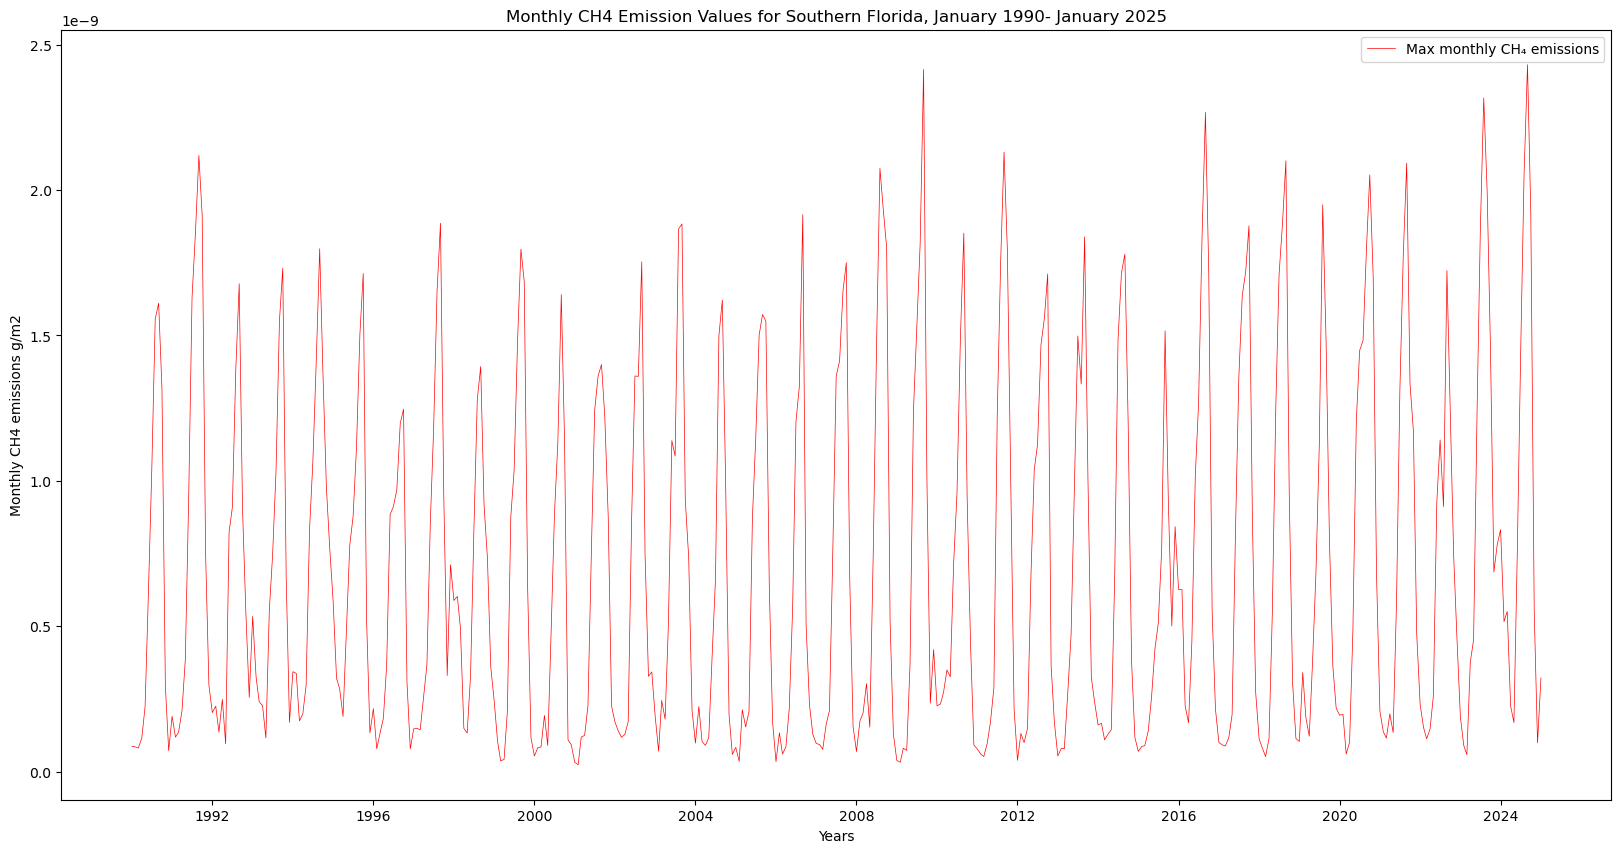

In [36]:
# Determine the width and height of the plot using the 'matplotlib' library
# Figure size: 20 representing the width, 10 representing the height
fig = plt.figure(figsize=(20, 10))

# Plot the time series
plt.plot(
    df["date"], # X-axis: date
    df["max"], # Y-axis: CH₄ value
    color="red", # Line color
    linestyle="-", # Line style
    linewidth=0.5, # Line width
    label="Max monthly CH₄ emissions", # Legend label
)

# Display legend
plt.legend()

# Insert label for the X-axis
plt.xlabel("Years")

# Insert label for the Y-axis
plt.ylabel("Monthly CH4 emissions g/m2")

# Insert title for the plot
plt.title("Monthly CH4 Emission Values for Southern Florida, January 1990- January 2025")

## Summary

In this notebook, we have successfully completed the following steps for the Wetland Methane Emissions, LPJ-EOSIM Model dataset:

1.  Install and import the necessary libraries
2.  Fetch the collection from STAC using the appropriate endpoints
3.  Count the number of existing granules within the collection
4.  Map and compare the CH₄ levels over the southern Florida region for two distinctive years
5.  Create a table that displays the minimum, maximum, and sum of the CH₄ levels for a specified region
6.  Generate a time-series graph of the CH₄ levels for a specified region

If you have any questions regarding this user notebook, please contact us using the [feedback form](https://docs.google.com/forms/d/e/1FAIpQLSeVWCrnca08Gt_qoWYjTo6gnj1BEGL4NCUC9VEiQnXA02gzVQ/viewform).